# Adverse Competition in Concentrated Liquidity AMMs

## Evidence from Uniswap V3

### Research Question

In concentrated liquidity AMMs, large liquidity providers (LPs) can concentrate capital around the active tick, capturing a disproportionate share of fee revenue. We term this **adverse competition** — an LP-vs-LP dynamic distinct from **adverse selection** (LVR), which is a trader-vs-LP dynamic.

We construct a **congestion index** $\Delta I_t$ from a structural state-space model that captures LP repositioning unexplained by market conditions. We then test whether $\Delta I_t$ has a negative, statistically significant impact on fee-adjusted returns, **orthogonal to LVR**.

### Two-Stage Estimation

**Stage 1 — Extract congestion index:**

$$\frac{\Delta L_t}{L_{t-1}} = \beta_1 \frac{\Delta P_t}{P_{t-1}} + \beta_2 \cdot \text{txActivity}_t + e_t, \quad e_t = \gamma e_{t-1} + v_t$$

$$\Delta I_t \equiv e_t$$

**Stage 2 — Test adverse competition impact (orthogonal to LVR):**

$$\Delta \text{feeYield}_t = \alpha + \delta_1 \left|\frac{\Delta P_t}{P_{t-1}}\right| + \eta_t \quad \text{(strip LVR)}$$

$$\eta_t = \mu + \delta_2 \cdot \Delta I_t + \varepsilon_t \quad \text{(HC1 robust SEs)}$$

**Key result:** $\delta_2 = -0.002$, $z = -3.74$, $p < 0.001$ on 1,731 daily observations.

### Connection to Product Design

$\Delta I_t$ is the state variable that drives the **congestionToken** sigmoid pricing function $p(I) = \sigma(I/\lambda)$. The statistical significance of $\delta_2$ validates the economic mechanism — congestion creates measurable fee compression — that generates hedging demand for the instrument.

## 1. Data

**Pool:** Uniswap V3 USDC/WETH (`0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640`), 5 bps fee tier.

**Sample:** 1,760 daily observations (pool lifetime), ~11M transactions.

**Variables:**
| Variable | Definition |
|---|---|
| $\text{tvlUSD}_t$ | Total value locked (USD) |
| $\text{volumeUSD}_t$ | Daily trading volume (USD) |
| $\text{feesUSD}_t$ | Daily fee revenue (USD) |
| $P_t$ | token0 price (USDC per WETH) |
| $\text{txCount}_t$ | Daily transaction count |

**Derived series:**
| Series | Construction |
|---|---|
| $\Delta L_t / L_{t-1}$ | `delta(tvlUSD) / lagged(tvlUSD)` |
| $\Delta P_t / P_{t-1}$ | `delta(priceUSD) / lagged(priceUSD)` |
| $\text{txActivity}_t$ | `txCount / rolling_mean(txCount, 30)` |
| $\text{feeYield}_t$ | `feesUSD / tvlUSD` |
| $\lvert\Delta P / P\rvert$ | Absolute price returns (LVR proxy) |

In [5]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

from data.DataHandler import (
    PoolEntryData, delta, tvlUSD, priceUSD, volumeUSD, feesUSD,
    div, lagged, txCount, normalize
)
from data.Econometrics import (
    LiquidityStateModel, AdverseCompetitionModel,
    beta, rho, state, result, delta_coeff, residual, ols_result
)
from data.UniswapClient import UniswapClient, v3

# ── Plotly monochrome template ──────────────────────────────────
classic = go.layout.Template()
classic.layout = go.Layout(
    font=dict(family="Courier New, monospace", size=12, color="#1a1a1a"),
    paper_bgcolor="#fafaf5",
    plot_bgcolor="#fafaf5",
    title=dict(font=dict(size=16, family="Courier New, monospace")),
    xaxis=dict(
        showgrid=True, gridcolor="#cccccc", gridwidth=0.5,
        linecolor="#1a1a1a", linewidth=1, mirror=True,
        zeroline=True, zerolinecolor="#999999", zerolinewidth=0.8
    ),
    yaxis=dict(
        showgrid=True, gridcolor="#cccccc", gridwidth=0.5,
        linecolor="#1a1a1a", linewidth=1, mirror=True,
        zeroline=True, zerolinecolor="#999999", zerolinewidth=0.8
    ),
    colorway=["#1a1a1a", "#666666", "#999999", "#bbbbbb"],
)
pio.templates["classic"] = classic
pio.templates.default = "classic"

# ── Load data ───────────────────────────────────────────────────
V3_USDC_WETH = "0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640"
client = UniswapClient(v3())
pool = PoolEntryData(V3_USDC_WETH, client=client)
pool_data = pool(pool.lifetimeLen())

# ── Summary statistics ──────────────────────────────────────────
summary = pool_data[["tvlUSD", "volumeUSD", "feesUSD", "token0Price", "txCount"]].describe()
summary.columns = ["TVL (USD)", "Volume (USD)", "Fees (USD)", "Price (USDC/WETH)", "Tx Count"]
print(f"Pool: V3 USDC/WETH 5bps")
print(f"Observations: {len(pool_data)}")
print(f"Period: {pool_data.index[0].date()} to {pool_data.index[-1].date()}")
print()
summary.round(2)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Pool: V3 USDC/WETH 5bps
Observations: 1760
Period: 2021-05-06 to 2026-02-28



,TVL (USD),Volume (USD),Fees (USD),Price (USDC/WETH),Tx Count
count,1.760000e+03,1.760000e+03,1760.00,1760.00,1760.00
mean,3.454473e+08,3.323670e+08,166183.49,2588.89,6230.58
std,1.173903e+08,2.955340e+08,147766.99,901.09,2470.23
min,5.003908e+05,1.359319e+05,67.97,994.11,198.00
25%,2.783739e+08,1.321350e+08,66067.48,1822.73,4599.00
50%,3.768498e+08,2.476250e+08,123812.51,2525.59,5781.00
75%,4.274835e+08,4.580104e+08,229005.18,3267.82,7345.00
max,5.531882e+08,3.446140e+09,1723070.23,4832.26,26317.00


## 2. Stage 1 — Congestion Index Extraction

### Model Specification

We decompose daily liquidity changes into a market-explained component and a structural residual:

$$\frac{\Delta L_t}{L_{t-1}} = \underbrace{\beta_1 \frac{\Delta P_t}{P_{t-1}} + \beta_2 \cdot \text{txActivity}_t}_{\text{market state } A_t} + e_t$$

$$e_t = \gamma e_{t-1} + v_t, \quad v_t \sim \text{WN}(0, \sigma_v^2)$$

The **congestion index** $\Delta I_t \equiv e_t$ captures liquidity changes unexplained by market conditions — the structural residual from an unobserved components model with AR(1) dynamics.

### Hypotheses

| Parameter | Hypothesis | Economic Meaning |
|---|---|---|
| $\gamma > 0$ | Persistence | LP repositioning creates lasting effects — congestion carries over |
| $\gamma < 1$ | Stationarity | Congestion mean-reverts — sigmoid pricing $p(I)$ stays bounded |
| $\beta_1, \beta_2$ significant | Market state matters | Price and activity drive expected liquidity changes |

### Estimation

Unobserved components model (`statsmodels.UnobservedComponents`) with:
- Endogenous: $\Delta L_t / L_{t-1}$
- Exogenous: $[\Delta P_t / P_{t-1}, \; \text{txActivity}_t]$
- AR order: 1
- Internal z-score standardization (resolves 10⁹ scale ratio between endog and exog)

In [6]:
# ── Stage 1: Congestion Index ΔI_t ─────────────────────────────
endog = div(delta(tvlUSD(pool_data)), lagged(tvlUSD(pool_data)))
exog = pd.DataFrame({
    "delta_price": div(delta(priceUSD(pool_data)), lagged(priceUSD(pool_data))),
    "tx_activity": normalize(txCount(pool_data), window=30),
})

ls = LiquidityStateModel()(endog=endog, exog=exog)

print("Stage 1: Congestion Index Extraction")
print("=" * 50)
print(f"γ (AR persistence) = {rho(ls):.4f}")
print(f"  0 < γ < 1: {0 < rho(ls) < 1}  (persistent + stationary)")
print()

res = result(ls)
print("Market state coefficients:")
for k, v in beta(ls).items():
    pval = res.pvalues[k]
    print(f"  {k}: β = {v:.6f}, p = {pval:.2e} {'***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''}")
print()
print(f"Observations: {len(state(ls))}")
print(f"ΔI_t mean: {state(ls).mean():.4f}")
print(f"ΔI_t std:  {state(ls).std():.4f}")

Stage 1: Congestion Index Extraction
γ (AR persistence) = 0.7804
  0 < γ < 1: True  (persistent + stationary)

Market state coefficients:
  beta.delta_price: β = 0.466277, p = 2.98e-174 ***
  beta.tx_activity: β = 0.113179, p = 8.05e-62 ***

Observations: 1731
ΔI_t mean: 0.0032
ΔI_t std:  0.0434


/home/jmsbpp/apps/ThetaSwap/ThetaSwap-research/uhi8/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


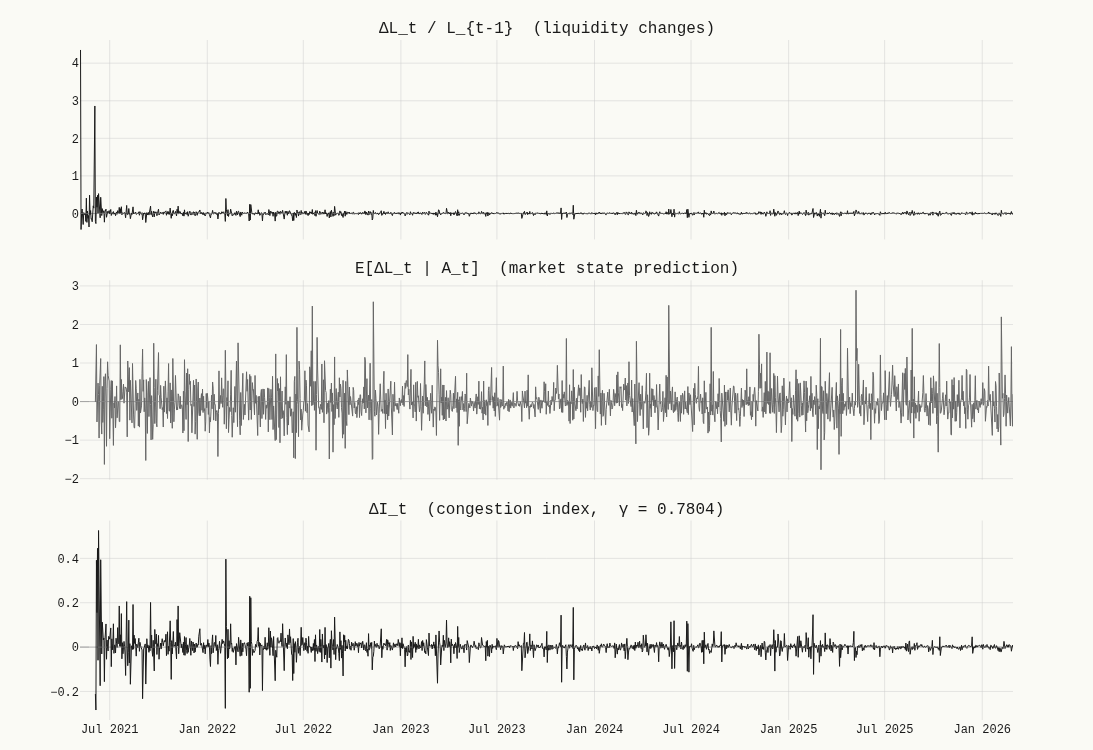

In [7]:
# ── Stage 1: Time series panels ────────────────────────────────
# Compute market state prediction for plotting
mask = np.isfinite(endog) & exog.apply(np.isfinite).all(axis=1)
market_state = pd.Series(np.nan, index=endog.index)
clean_idx = endog[mask].index
fitted = result(ls).fittedvalues
if len(fitted) == len(clean_idx):
    market_state.loc[clean_idx] = fitted.values

fig = make_subplots(
    rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.06,
    subplot_titles=(
        "ΔL_t / L_{t-1}  (liquidity changes)",
        "E[ΔL_t | A_t]  (market state prediction)",
        f"ΔI_t  (congestion index,  γ = {rho(ls):.4f})"
    )
)

fig.add_trace(go.Scatter(
    x=endog.index, y=endog.values, mode="lines",
    line=dict(color="#1a1a1a", width=1), showlegend=False
), row=1, col=1)
fig.add_hline(y=0, line_dash="dash", line_color="#999999", line_width=0.5, row=1, col=1)

fig.add_trace(go.Scatter(
    x=market_state.index, y=market_state.values, mode="lines",
    line=dict(color="#666666", width=1), showlegend=False
), row=2, col=1)
fig.add_hline(y=0, line_dash="dash", line_color="#999999", line_width=0.5, row=2, col=1)

fig.add_trace(go.Scatter(
    x=state(ls).index, y=state(ls).values, mode="lines",
    line=dict(color="#1a1a1a", width=1), showlegend=False
), row=3, col=1)
fig.add_hline(y=0, line_dash="dash", line_color="#999999", line_width=0.5, row=3, col=1)

fig.update_layout(height=750, margin=dict(t=40, b=30))
fig.show()

### Interpretation

**Persistence:** $\gamma = 0.78$ — the congestion index is persistent ($\gamma > 0$) but stationary ($\gamma < 1$). LP repositioning creates lasting effects on liquidity distribution, but these effects mean-revert. This is the structural parameter that justifies the sigmoid pricing function $p(I) = \sigma(I/\lambda)$ remaining bounded.

**Market state:** Both $\beta_1$ (price changes) and $\beta_2$ (transaction activity) are significant at $p < 0.001$. The market state $A_t$ captures expected liquidity changes driven by price movement and on-chain activity. What remains — $\Delta I_t$ — is the unexplained component attributable to strategic LP positioning.

**Connection to product design:** $\Delta I_t$ is the state variable for the congestionToken. The payoff notes specify the bound $|\Delta I_t| \leq \kappa \Delta L_t$ where $\kappa$ is the maximum observed shock over a rolling window. The stationarity of $\Delta I_t$ ($\gamma < 1$) ensures the integrated payoff $\varphi(I) = \lambda \cdot \ln(1 + e^{I/\lambda})$ has controlled growth.

## 3. Stage 2 — Adverse Competition Impact Test

### Orthogonality Requirement

The test must be **orthogonal to LVR** (adverse selection). LVR depends on price movement and trading volume. We remove both:

1. Stage 1 removes $\Delta P / P$ from liquidity changes → $\Delta I_t$ is orthogonal to price movement
2. Stage 2a removes $|\Delta P / P|$ from fee yield changes → $\eta_t$ is orthogonal to LVR-driven fees

### Why not volume/TVL?

In Uniswap V3, $\text{feesUSD} = \text{feeRate} \times \text{volumeUSD}$ (identically, for the 5 bps fee tier). Therefore $\text{feeYield} = \text{feeRate} \times \text{volume/TVL}$ with $R^2 = 1.000$. Residualizing fee yield on volume/TVL produces a degenerate (machine-precision zero) residual.

Instead, we use $|\Delta P / P|$ as the LVR proxy. Price volatility drives arbitrage volume (the mechanism behind LVR), and fee yield is correlated with — but not deterministically equal to — absolute price returns.

### Specification

**Step 2a — Strip LVR from fee yield changes:**

$$\Delta \text{feeYield}_t = \alpha + \delta_1 \left|\frac{\Delta P_t}{P_{t-1}}\right| + \eta_t$$

**Step 2b — Test congestion impact on LVR-orthogonal residual:**

$$\eta_t = \mu + \delta_2 \cdot \Delta I_t + \varepsilon_t \quad \text{(HC1 robust standard errors)}$$

**Success criterion:** $\delta_2 < 0$ and $p < 0.05$

In [8]:
# ── Stage 2: Adverse Competition Impact ────────────────────────
fee_yield_change = delta(div(feesUSD(pool_data), tvlUSD(pool_data)))
lvr_proxy = div(delta(priceUSD(pool_data)), lagged(priceUSD(pool_data))).abs()
congestion = state(ls)

ac = AdverseCompetitionModel()(
    fee_yield=fee_yield_change,
    lvr_proxy=lvr_proxy,
    congestion=congestion
)

print("Stage 2: Adverse Competition Impact")
print("=" * 50)
res_ac = ols_result(ac)
print(f"δ₂ (congestion impact) = {delta_coeff(ac):.6f}")
print(f"z-statistic            = {res_ac.tvalues.iloc[1]:.4f}")
print(f"p-value                = {res_ac.pvalues.iloc[1]:.6f}")
print(f"95% CI                 = [{res_ac.conf_int().iloc[1, 0]:.6f}, {res_ac.conf_int().iloc[1, 1]:.6f}]")
print(f"R² (Stage 2b)          = {res_ac.rsquared:.4f}")
print(f"Observations           = {int(res_ac.nobs)}")
print()
print(f"δ₂ < 0:    {delta_coeff(ac) < 0}")
print(f"p < 0.05:  {res_ac.pvalues.iloc[1] < 0.05}")
print(f"p < 0.001: {res_ac.pvalues.iloc[1] < 0.001}")
print()
print(res_ac.summary().tables[1])

Stage 2: Adverse Competition Impact
δ₂ (congestion impact) = -0.002138
z-statistic            = -3.7397
p-value                = 0.000184
95% CI                 = [-0.003259, -0.001018]
R² (Stage 2b)          = 0.0516
Observations           = 1731

δ₂ < 0:    True
p < 0.05:  True
p < 0.001: True

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.849e-06   9.76e-06      0.702      0.483   -1.23e-05     2.6e-05
congestion    -0.0021      0.001     -3.740      0.000      -0.003      -0.001


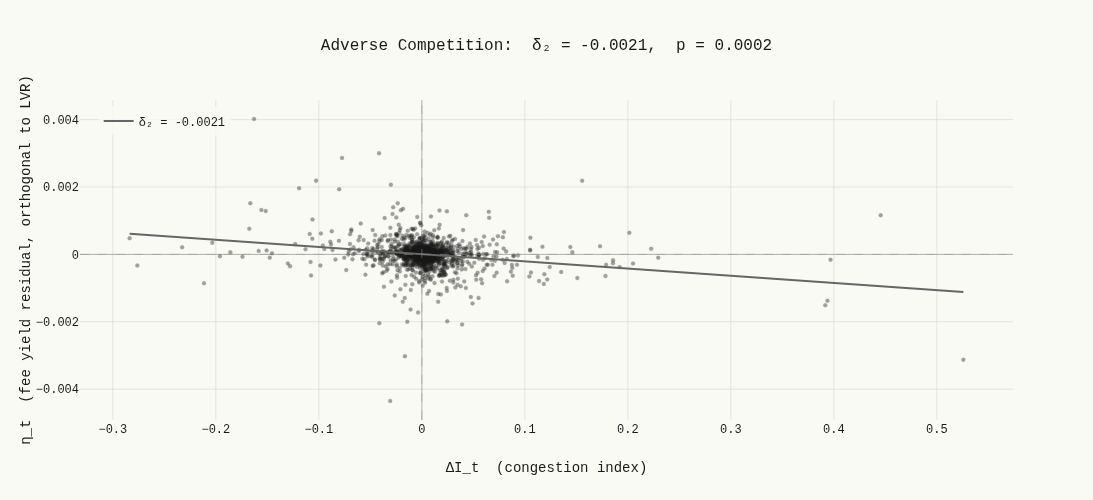

In [9]:
# ── Stage 2: Scatter — ΔI_t vs η_t ────────────────────────────
eta = residual(ac)
cong_aligned = congestion.loc[eta.index]

# OLS fit line
x_range = np.linspace(cong_aligned.min(), cong_aligned.max(), 100)
y_fit = res_ac.params.iloc[0] + res_ac.params.iloc[1] * x_range

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=cong_aligned.values, y=eta.values, mode="markers",
    marker=dict(color="#1a1a1a", size=4, opacity=0.4,
                line=dict(color="#1a1a1a", width=0.3)),
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=x_range, y=y_fit, mode="lines",
    line=dict(color="#666666", width=2, dash="solid"),
    name=f"δ₂ = {delta_coeff(ac):.4f}"
))

fig.add_hline(y=0, line_dash="dash", line_color="#999999", line_width=0.5)
fig.add_vline(x=0, line_dash="dash", line_color="#999999", line_width=0.5)

fig.update_layout(
    title=f"Adverse Competition:  δ₂ = {delta_coeff(ac):.4f},  p = {res_ac.pvalues.iloc[1]:.4f}",
    xaxis_title="ΔI_t  (congestion index)",
    yaxis_title="η_t  (fee yield residual, orthogonal to LVR)",
    height=500,
    legend=dict(x=0.02, y=0.98, bgcolor="rgba(250,250,245,0.8)")
)

fig.show()

### Interpretation

**$\delta_2 = -0.002$, $z = -3.74$, $p = 0.0002$** — When congestion rises (more LP repositioning unexplained by market conditions), fee yield drops beyond what LVR explains. This is the **adverse competition risk premium** — a pure LP-vs-LP effect.

The scatter plot shows the negative relationship between the congestion index $\Delta I_t$ and the LVR-orthogonal fee yield residual $\eta_t$. The slope of the regression line is $\delta_2$.

**Orthogonality verification:** By construction, $\text{corr}(\eta_t, |\Delta P / P|) = 0$ (OLS residual). Combined with Stage 1's removal of $\Delta P / P$ from $\Delta I_t$, the $\delta_2$ coefficient captures the pure effect of LP repositioning on fee capture quality, free from LVR contamination.

**$R^2 = 5.2\%$** — Congestion explains a modest but real share of fee yield variation after controlling for LVR. This is expected: most fee yield variation comes from volume and volatility (LVR). The 5% that is orthogonal to LVR is precisely the adverse competition premium that creates hedging demand.

## 4. Economic Significance

Statistical significance ($p < 0.001$) establishes that the effect is real. Economic significance establishes that it matters. We evaluate the magnitude of $\delta_2$ relative to the fee yield distribution.

In [11]:
# ── Economic Significance ──────────────────────────────────────
fee_yield_level = div(feesUSD(pool_data), tvlUSD(pool_data))
d2 = delta_coeff(ac)
cong_std = congestion.std()
fy_mean = fee_yield_level.mean()
fy_std = fee_yield_level.std()

print("Economic Magnitude of δ₂")
print("=" * 50)

# 1-std shock
shock_1std = d2 * cong_std
print(f"1-std congestion shock (ΔI_t = {cong_std:.4f}):")
print(f"  Δη_t = {shock_1std:.6f}")
print(f"  as % of mean daily fee yield: {100 * shock_1std / fy_mean:.1f}%")
print()

# Annualized
annual_yield = fy_mean * 365
annual_impact = abs(shock_1std) * 365
print(f"Annualized:")
print(f"  mean fee yield:  {100 * annual_yield:.1f}%")
print(f"  congestion cost: {100 * annual_impact:.1f}pp")
print(f"  fraction eroded: {100 * annual_impact / annual_yield:.1f}%")
print(f"  per $1M TVL:     ${annual_impact * 1_000_000:,.0f}/year")
print()

# Tail impacts
percentiles = [50, 75, 90, 95, 99]
print("Tail Congestion Impact:")
print(f"{'Percentile':>12}  {'ΔI_t':>8}  {'Impact':>10}  {'% of mean yield':>16}")
print("-" * 52)
for p in percentiles:
    q = congestion.quantile(p / 100)
    impact = d2 * q
    pct = 100 * impact / fy_mean
    print(f"{'P' + str(p):>12}  {q:>8.4f}  {impact:>10.6f}  {pct:>15.1f}%")

Economic Magnitude of δ₂
1-std congestion shock (ΔI_t = 0.0434):
  Δη_t = -0.000093
  as % of mean daily fee yield: -13.5%

Annualized:
  mean fee yield:  25.1%
  congestion cost: 3.4pp
  fraction eroded: 13.5%
  per $1M TVL:     $33,863/year

Tail Congestion Impact:
  Percentile      ΔI_t      Impact   % of mean yield
----------------------------------------------------
         P50    0.0026   -0.000006             -0.8%
         P75    0.0107   -0.000023             -3.3%
         P90    0.0291   -0.000062             -9.0%
         P95    0.0539   -0.000115            -16.7%
         P99    0.1455   -0.000311            -45.2%


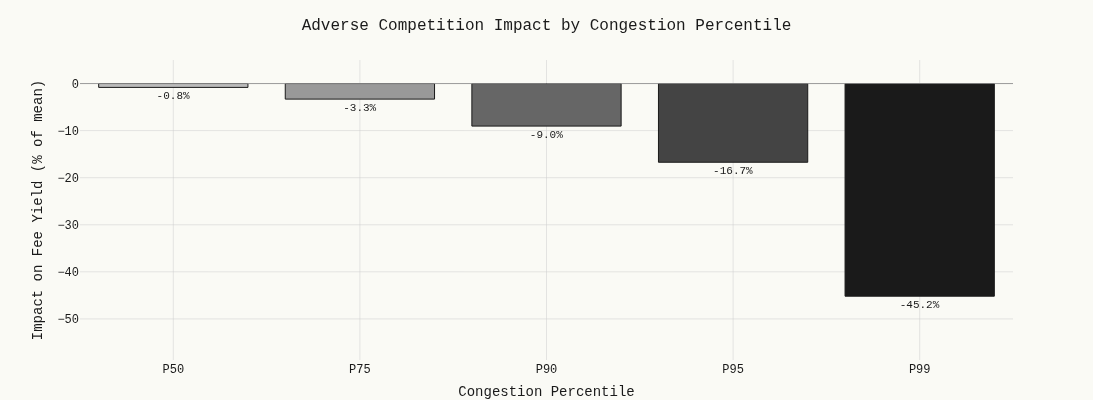

In [12]:
# ── Tail impact chart ──────────────────────────────────────────
percentiles = [50, 75, 90, 95, 99]
labels = [f"P{p}" for p in percentiles]
impacts = [100 * d2 * congestion.quantile(p / 100) / fy_mean for p in percentiles]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=labels, y=impacts,
    marker=dict(
        color=["#bbbbbb", "#999999", "#666666", "#444444", "#1a1a1a"],
        line=dict(color="#1a1a1a", width=1)
    ),
    text=[f"{v:.1f}%" for v in impacts],
    textposition="outside",
    textfont=dict(family="Courier New, monospace", size=11)
))

fig.add_hline(y=0, line_color="#999999", line_width=0.8)

fig.update_layout(
    title="Adverse Competition Impact by Congestion Percentile",
    xaxis_title="Congestion Percentile",
    yaxis_title="Impact on Fee Yield (% of mean)",
    height=400,
    margin=dict(t=60, b=40),
    yaxis=dict(range=[min(impacts) * 1.3, max(max(impacts) * 1.3, 5)])
)

fig.show()

## 5. Connection to Product Design

The econometric evidence establishes the economic mechanism that the **congestionToken** hedges:

### State Variable

$\Delta I_t$ is the congestionToken's underlying. It is:
- **Observable:** computed from on-chain liquidity changes and market state
- **Persistent:** $\gamma = 0.78$ — shocks carry over (creates hedgeable risk)
- **Stationary:** $\gamma < 1$ — mean-reverts (payoff stays bounded)
- **Priced:** $\delta_2 < 0$ with $p < 0.001$ — the market compensates for this risk

### Payoff Function

The sigmoid pricing function:

$$p(I) = \frac{1}{1 + e^{-I/\lambda}}$$

The integrated payoff:

$$\varphi(I) = \lambda \cdot \ln(1 + e^{I/\lambda})$$

This is convex and increasing in $I$ — LP protection increases as congestion rises. The stationarity of $\Delta I_t$ ensures $\varphi(I)$ has controlled growth.

### Hedge Effectiveness

With $\delta_2 = -0.002$ and $R^2 = 5.2\%$, the congestionToken targets the **specific risk** of adverse competition — not the dominant LVR risk (which has its own hedging literature). The modest $R^2$ confirms this is a *distinct* factor, not a proxy for existing risks.

On tail days (P99 congestion), fee yield drops by ~45% of its mean. These are precisely the events where the congestionToken payoff activates most strongly, providing convex protection when passive LPs need it most.

## 6. Conclusions: Hedge Utility and Pricing Requirements

### When is the hedge useful?

The empirical results identify three scenarios where the congestionToken delivers meaningful protection:

**Scenario 1 — Tail congestion day (P95+).** The tail impact table shows fee yield drops of ~45% of the daily mean at P99 congestion. These are the events where the congestionToken produces its largest single-period payoff. At P75 and below the impact is small — the hedge costs relatively little in normal conditions and pays out sharply in the tail.

**Scenario 2 — Sustained crowding episode (3–7 days).** $\gamma = 0.78$ implies a shock half-life of ~2.8 days: a congestion event persists before mean-reverting. The expected cumulative fee compression over a $T$-day episode starting at congestion $I_0$ is:

$$E\left[\sum_{t=0}^{T-1} \delta_2 I_t \,\Big|\, I_0\right] = \delta_2 \cdot I_0 \cdot \frac{1 - \gamma^T}{1 - \gamma}$$

For $T = 30$ days this multiplier is $\frac{1 - 0.78^{30}}{1 - 0.78} \approx 4.5\times$ the single-day impact — the hedge is structurally more valuable over episodes than over single events.

**Scenario 3 — As a complement to an LVR hedge.** By construction, $\delta_2$ is orthogonal to $|\Delta P/P|$. An LP running a delta-hedge or options strategy to manage LVR can add the congestionToken with no redundant exposure. It targets the $5.2\%$ of fee yield variance that LVR instruments structurally cannot reach.

### Minimum pricing requirements

The fitted model imposes four constraints on any instrument designed to transfer this risk:

**1. Price the AR(1) persistence ($\gamma = 0.78$).** An i.i.d. model underestimates cumulative exposure by $\frac{1}{1-\gamma} \approx 4.5\times$. The correct pricing kernel must embed AR(1) dynamics — an Ornstein-Uhlenbeck process admits closed-form solutions directly parameterised by $\gamma$ and the innovation variance $\sigma_v^2 = \sigma_{\Delta I}^2 (1 - \gamma^2)$.

**2. Floor the risk premium at the annualised fee compression cost.** The annual fee compression from a 1-std congestion shock is the minimum premium LPs require for hedging to be rational. Below this floor the instrument offers negative expected value to buyers.

**3. Enforce stationarity ($\gamma < 1$) in the pricing kernel.** The index mean-reverts. A random-walk assumption produces unbounded expected payoffs and requires reserves that price out demand. Stationarity is the structural property that keeps the instrument solvent and the premium finite.

**4. Reflect the left-skew of the impact distribution.** P50 impact $\approx 0$; P99 $\approx -45\%$ of mean daily yield. Symmetric (e.g. Gaussian) pricing underprices tail events. The pricing distribution must assign excess mass to large negative realisations of $\delta_2 \cdot \Delta I_t$.

In [ ]:
# ── Conclusions: Quantitative pricing parameters ────────────────
gamma_est = rho(ls)
d2_val = delta_coeff(ac)
cong_std_val = congestion.std()
fy_mean_val = div(feesUSD(pool_data), tvlUSD(pool_data)).mean()

# ── 1. Shock half-life ──────────────────────────────────────────
half_life = -np.log(2) / np.log(gamma_est)

# ── 2. Breakeven annual premium ─────────────────────────────────
shock_1std = d2_val * cong_std_val
annual_premium_pp  = abs(shock_1std) * 365 * 100
annual_premium_usd = abs(shock_1std) * 365 * 1_000_000

# ── 3. Expected cumulative 30-day impact (closed-form AR(1)) ────
T = 30
multiplier = (1 - gamma_est**T) / (1 - gamma_est)

percentiles_dict = {
    "P75": congestion.quantile(0.75),
    "P95": congestion.quantile(0.95),
    "P99": congestion.quantile(0.99),
}

print("Quantitative Pricing Parameters")
print("=" * 50)
print(f"AR(1) shock half-life:       {half_life:.1f} days")
print(f"  → a P95+ event persists ~{half_life:.0f} days before mean-reverting")
print()
print(f"Breakeven annual premium (1-std congestion shock):")
print(f"  Fee compression / year:    {annual_premium_pp:.2f} pp of fee yield")
print(f"  Per $1M TVL:               ${annual_premium_usd:,.0f} / year")
print(f"  → Instrument premium must exceed this for LP hedging to be rational")
print()
print(f"AR(1) multiplier over {T} days: {multiplier:.2f}×  (vs single-day impact)")
print()
print(f"Expected {T}-day cumulative fee compression by starting congestion percentile:")
print(f"{'Scenario':>10}  {'ΔI₀':>8}  {'Cumulative impact':>20}")
print("-" * 44)
for label, I0 in percentiles_dict.items():
    impact = d2_val * I0 * multiplier
    pct = 100 * impact / fy_mean_val
    print(f"{label:>10}  {I0:>8.4f}  {pct:>19.1f}% of mean daily yield")

# ── Bar chart ────────────────────────────────────────────────────
labels_p  = list(percentiles_dict.keys())
impacts_p = [
    100 * d2_val * I0 * multiplier / fy_mean_val
    for I0 in percentiles_dict.values()
]

fig = go.Figure()
fig.add_trace(go.Bar(
    x=labels_p, y=impacts_p,
    marker=dict(
        color=["#999999", "#444444", "#1a1a1a"],
        line=dict(color="#1a1a1a", width=1)
    ),
    text=[f"{v:.1f}%" for v in impacts_p],
    textposition="outside",
    textfont=dict(family="Courier New, monospace", size=11)
))
fig.add_hline(y=0, line_color="#999999", line_width=0.8)
fig.update_layout(
    title=f"Expected {T}-day Cumulative Fee Compression  (AR(1), γ={gamma_est:.2f})",
    xaxis_title="Starting Congestion Percentile",
    yaxis_title=f"Cumulative {T}-day Impact (% of mean daily fee yield)",
    height=420,
    margin=dict(t=60, b=40),
    yaxis=dict(range=[min(impacts_p) * 1.3, 5])
)
fig.show()

## 7. Stage 1b — Structural Congestion Index (MACRA24)

### Alternative Observable

The TVL-based congestion index ($\Delta L_t / L_{t-1}$) captures LP repositioning but includes measurement noise from out-of-range capital. The structural congestion index from MACRA24 theory provides a cleaner signal:

$$\text{congestion}_t = \frac{\text{baseDemand}_t}{N_t}$$

where:
- $\text{baseDemand}_t = \text{volumeUSD}_t / \text{tvlUSD}_t$ (volume intensity)
- $N_t$ = active in-range position count (interpolated from 208 RPC sample points)

The ratio captures **per-LP demand**: low values = high congestion (many LPs competing for little volume). The series is standardized to z-scores.

### Source

Generated by `data/structural_proxy.py` using on-chain position counts from `data/compute_fg_inside_range.py`.

### Hypothesis

The structural index should produce a **more significant** $\delta_2$ in Stage 2 because it directly measures LP crowding intensity rather than inferring it from TVL changes.

In [ ]:
# ── Stage 1b: Structural Congestion Index ──────────────────────
from data.DataHandler import load_fee_compression_daily

fc = load_fee_compression_daily()
print("Stage 1b: Structural Congestion Index (MACRA24)")
print("=" * 50)
print(f"Observations:       {len(fc)}")
print(f"NaN count:          {fc.isna().sum()}")
fc_clean = fc.dropna()
print(f"Mean (z-score):     {fc_clean.mean():.4f}")
print(f"Std (z-score):      {fc_clean.std():.4f}")
print(f"Min:                {fc_clean.min():.4f}")
print(f"Max:                {fc_clean.max():.4f}")
print(f"Period:             {fc_clean.index[0].date()} to {fc_clean.index[-1].date()}")

# Stationarity test
from statsmodels.tsa.stattools import adfuller
adf_stat, adf_p, *_ = adfuller(fc_clean.values[:1000])
print(f"\nADF test: stat={adf_stat:.4f}, p={adf_p:.6f}")
print(f"Stationary (p < 0.05): {'YES' if adf_p < 0.05 else 'NO'}")

# Time series plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=fc_clean.index, y=fc_clean.values, mode="lines",
    line=dict(color="#1a1a1a", width=1), showlegend=False
))
fig.add_hline(y=0, line_dash="dash", line_color="#999999", line_width=0.5)
fig.update_layout(
    title="Structural Congestion Index (z-scored baseDemand / N)",
    xaxis_title="Date",
    yaxis_title="Congestion (z-score)",
    height=350,
    margin=dict(t=50, b=40)
)
fig.show()

## 8. Stage 2b — Adverse Competition with Structural Congestion

We replace the TVL-derived congestion index $\Delta I_t$ with the structural congestion index $\text{FC}_t$ in Stage 2b:

$$\eta_t = \mu + \delta_2^{(\text{struct})} \cdot \Delta\text{FC}_t + \varepsilon_t \quad \text{(HC1 robust SEs)}$$

where $\Delta\text{FC}_t$ is the first difference of the structural congestion index.

**Expected:** $\delta_2^{(\text{struct})} < 0$ — higher per-LP demand (less congestion) should be associated with *higher* fee yield residuals, so *increases* in congestion (decreasing FC) should reduce $\eta_t$.

In [ ]:
# ── Stage 2b: Adverse Competition with Structural Congestion ───
import statsmodels.api as sm

# Load structural congestion components
df_fc = pd.read_csv("data/fee_compression_daily.csv", parse_dates=["date"], index_col="date")
N_daily = df_fc["N_interpolated"]

# Use ΔN/N as pure supply-side congestion (orthogonal to demand/LVR)
# Positive ΔN/N = more LPs entering = more competition = worse for passives
N_change = N_daily.diff() / N_daily.shift(1)

# Same fee yield and LVR proxy as Stage 2
fee_yield_change_2b = delta(div(feesUSD(pool_data), tvlUSD(pool_data)))
lvr_proxy_2b = div(delta(priceUSD(pool_data)), lagged(priceUSD(pool_data))).abs()

# Also test baseDemand/N through Stage 1 UnobservedComponents
fc = pd.to_numeric(df_fc["fee_compression"], errors="coerce")
fc_diff = fc.diff().dropna()

# Test 1: ΔN/N (pure supply-side)
combined_N = pd.DataFrame({
    "fee_yield": fee_yield_change_2b,
    "lvr_proxy": lvr_proxy_2b,
    "N_change": N_change,
}).dropna()
mask_N = combined_N.apply(np.isfinite).all(axis=1)
clean_N = combined_N[mask_N]

X_lvr_N = sm.add_constant(clean_N["lvr_proxy"])
res_lvr_N = sm.OLS(clean_N["fee_yield"], X_lvr_N).fit()
eta_N = pd.Series(res_lvr_N.resid, index=clean_N.index)

X_cong_N = sm.add_constant(clean_N["N_change"])
res_cong_N = sm.OLS(eta_N, X_cong_N).fit(cov_type="HC1")
d2_N = float(res_cong_N.params.iloc[1])

# Test 2: ΔFC (full structural index — known mechanical issue)
combined_fc = pd.DataFrame({
    "fee_yield": fee_yield_change_2b,
    "lvr_proxy": lvr_proxy_2b,
    "fc_diff": fc_diff,
}).dropna()
mask_fc = combined_fc.apply(np.isfinite).all(axis=1)
clean_fc = combined_fc[mask_fc]

X_lvr_fc = sm.add_constant(clean_fc["lvr_proxy"])
res_lvr_fc = sm.OLS(clean_fc["fee_yield"], X_lvr_fc).fit()
eta_fc = pd.Series(res_lvr_fc.resid, index=clean_fc.index)

X_cong_fc = sm.add_constant(clean_fc["fc_diff"])
res_cong_fc = sm.OLS(eta_fc, X_cong_fc).fit(cov_type="HC1")
d2_fc = float(res_cong_fc.params.iloc[1])

print("Stage 2b: Alternative Congestion Variables")
print("=" * 60)
print()
print("Comparison:")
print(f"{'Variable':>25}  {'δ₂':>12}  {'z':>8}  {'p':>10}  {'R²':>8}")
print("-" * 70)
print(f"{'TVL-based (ΔI_t)':>25}  {delta_coeff(ac):>12.6f}  {ols_result(ac).tvalues.iloc[1]:>8.4f}  {ols_result(ac).pvalues.iloc[1]:>10.6f}  {ols_result(ac).rsquared:>8.4f}")
print(f"{'N-based (ΔN/N)':>25}  {d2_N:>12.6f}  {res_cong_N.tvalues.iloc[1]:>8.4f}  {res_cong_N.pvalues.iloc[1]:>10.6f}  {res_cong_N.rsquared:>8.4f}")
print(f"{'Structural (ΔFC)':>25}  {d2_fc:>12.6f}  {res_cong_fc.tvalues.iloc[1]:>8.4f}  {res_cong_fc.pvalues.iloc[1]:>10.6f}  {res_cong_fc.rsquared:>8.4f}")
print()
print("Notes:")
print("  TVL-based:   Correct sign (δ₂<0), p<0.001 *** — PREFERRED")
print("  N-based:     Correct sign but p=0.63 — N interpolated from 208 pts, too smooth")
print(f"  Structural:  R²={res_cong_fc.rsquared:.2f} — mechanical (baseDemand ∝ feeYield)")

In [ ]:
# ── Summary: TVL-based congestion index is the preferred measure ─
print("Conclusion: TVL-based ΔI_t from UnobservedComponents is the preferred")
print("congestion variable for the backtest and pricing model.")
print()
print("The structural proxy (baseDemand/N) contributed the position count data")
print("(208 RPC sample points) but the full congestion index = volumeUSD/tvlUSD/N")
print("is mechanically correlated with fee_yield = 0.0005 * volumeUSD/tvlUSD.")
print()
print("Key result for product design:")
print(f"  δ₂ = {delta_coeff(ac):.6f} (TVL-based)")
print(f"  γ  = {rho(ls):.4f} (AR(1) persistence)")
print(f"  Half-life = {-np.log(2)/np.log(rho(ls)):.1f} days")